In [13]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import librosa
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
import pickle
import pandas as pd
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
# should print: Device: cuda  (if RTX 2050 is detected)

Device: cuda


In [4]:
def load_pkl(data_file):
    
    file = open(data_file, 'rb') 
    dataset = pickle.load(file)

    df_dataset = pd.DataFrame(dataset, columns=["cqcc", "label"])
    df_dataset.to_csv('dataset.csv')

    train_set, test_set = train_test_split(df_dataset, test_size=0.3, random_state=42,stratify=df_dataset['label'] )

    train_set.to_csv('training_data.csv', index=False)

    test_set ,val_set = train_test_split(test_set, test_size=0.5, random_state=42,stratify=test_set['label'] )
    test_set.to_csv('test_data.csv', index=False)
    val_set.to_csv('val_data.csv', index=False)
    return train_set,test_set,val_set


In [ ]:
import sys
!{sys.executable} -m pip install numpy torch torchaudio librosa scikit-learn scipy matplotlib -q

In [ ]:
# ── change this to match your folder ──────────────────
DATA_ROOT = r'C:\dev\50.021\5sec'
SPEC_DIR  = r'C:\dev\50.021\specs_5sec'
MODEL_SAVE = r'C:\dev\50.021\best_unet_5sec.pt'
# ───────────────────────────────────────────────────────

os.makedirs(SPEC_DIR, exist_ok=True)

LABEL_MAP = {
    'REAL':     0,
    'human':    0,
    'FAKE':     1,
    'nonhuman': 1,
}

class AudioConfig:
    SR         = 16000
    DURATION   = 5.0
    SAMPLES    = int(SR * DURATION)
    N_FFT      = 512
    HOP_LENGTH = 160
    N_MELS     = 128
    FMIN       = 0
    FMAX       = 8000

In [ ]:
for folder in ['REAL', 'human', 'FAKE', 'nonhuman']:
    path = os.path.join(DATA_ROOT, folder)
    if os.path.exists(path):
        count = len([f for f in os.listdir(path)
                     if f.endswith(('.mp3', '.wav'))])
        print(f"{folder:12s}: {count} clips")
    else:
        print(f"{folder:12s}: NOT FOUND")

In [ ]:
all_files  = []
all_labels = []

for folder, label in LABEL_MAP.items():
    folder_path = Path(DATA_ROOT) / folder
    if not folder_path.exists():
        print(f"[warning] not found: {folder_path}")
        continue
    clips = list(folder_path.glob('*.mp3')) + \
            list(folder_path.glob('*.wav'))
    all_files  += [str(p) for p in clips]
    all_labels += [label] * len(clips)
    print(f"  {folder:12s} → label {label} | {len(clips)} clips")

print(f"\nTotal: {len(all_files)} clips  "
      f"({all_labels.count(0)} real, {all_labels.count(1)} fake)")

cache spectrogram

In [ ]:
print(f"Caching {len(all_files)} clips to {SPEC_DIR} ...")

for i, (fpath, label) in enumerate(zip(all_files, all_labels)):
    out = os.path.join(SPEC_DIR, f"{i}_{label}.npy")
    if os.path.exists(out):
        continue
    try:
        y, _ = librosa.load(fpath, sr=AudioConfig.SR,
                            mono=True, duration=AudioConfig.DURATION)
        if len(y) < AudioConfig.SAMPLES:
            y = np.pad(y, (0, AudioConfig.SAMPLES - len(y)))
        y = y[:AudioConfig.SAMPLES]
        S = librosa.feature.melspectrogram(
            y=y, sr=AudioConfig.SR,
            n_fft=AudioConfig.N_FFT,
            hop_length=AudioConfig.HOP_LENGTH,
            n_mels=AudioConfig.N_MELS,
        )
        S = librosa.power_to_db(S, ref=np.max)
        S = (S - S.min()) / (S.max() - S.min() + 1e-8)
        np.save(out, S.astype(np.float32))
    except Exception as e:
        print(f"  [skip] {fpath}: {e}")

    if i % 500 == 0:
        print(f"  {i}/{len(all_files)} done...")

print("Caching complete!")

cache dataset class

In [ ]:
class CachedDataset(Dataset):
    def __init__(self, spec_dir, fixed_h=128, fixed_w=256, augment=False):
        self.fixed_h = fixed_h
        self.fixed_w = fixed_w
        self.augment = augment
        self.files   = sorted(Path(spec_dir).glob('*.npy'),
                              key=lambda x: int(x.stem.split('_')[0]))
        self.labels  = [int(f.stem.split('_')[1]) for f in self.files]
        print(f"Loaded {len(self.files)} cached specs  "
              f"({self.labels.count(0)} real, {self.labels.count(1)} fake)")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        S = np.load(self.files[idx])[np.newaxis, ...]
        if self.augment:
            _, H, W = S.shape
            f  = np.random.randint(0, 15)
            f0 = np.random.randint(0, max(1, H - f))
            S[:, f0:f0+f, :] = 0
            t  = np.random.randint(0, 30)
            t0 = np.random.randint(0, max(1, W - t))
            S[:, :, t0:t0+t] = 0
        spec = torch.tensor(S, dtype=torch.float32)
        spec = F.interpolate(spec.unsqueeze(0),
                             size=(self.fixed_h, self.fixed_w),
                             mode='bilinear', align_corners=False).squeeze(0)
        return spec, torch.tensor(self.labels[idx], dtype=torch.float32)

In [ ]:
full_ds = CachedDataset(SPEC_DIR, augment=False)
aug_ds  = CachedDataset(SPEC_DIR, augment=False)

n       = len(full_ds)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

train_idx, val_idx, test_idx = random_split(
    range(n), [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

# batch size 8 for RTX 2050 (4GB VRAM)
train_loader = DataLoader(
    torch.utils.data.Subset(aug_ds,  train_idx.indices),
    batch_size=8, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(
    torch.utils.data.Subset(full_ds, val_idx.indices),
    batch_size=8, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(
    torch.utils.data.Subset(full_ds, test_idx.indices),
    batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

In [5]:
class AudioDatasetV2(Dataset):
    def __init__(self, samples: pd.DataFrame):
        self.samples = samples

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        spectrogram, label = self.samples.iloc[idx]
        

        spectrogram_tensor = torch.tensor(spectrogram, dtype=torch.float32)
        label_tensor = torch.tensor(label, dtype=torch.float32)
        time_steps = spectrogram_tensor.shape[1]

        return spectrogram_tensor, label_tensor, time_steps


In [6]:
train_samples,test_samples,val_samples = load_pkl("10s_log_mel_shuffled.pkl")

print(f"\nTrain size: {len(train_samples)}")
print(f"Validation size: {len(val_samples)}")
print(f"Test size: {len(test_samples)}")


train_dataset = AudioDatasetV2(train_samples)
val_dataset = AudioDatasetV2(val_samples)
test_dataset = AudioDatasetV2(test_samples)


Train size: 5355
Validation size: 1148
Test size: 1148


In [7]:
def collate_fn(batch):
    spectrograms, labels, lengths = zip(*batch)

    specs_for_padding = [spec.T for spec in spectrograms]  # (time, mel)
    padded = pad_sequence(specs_for_padding, batch_first=True)  # (batch, max_time, mel)

    lengths_tensor = torch.tensor(lengths, dtype=torch.long)
    labels_tensor = torch.stack(labels)

    # (batch, max_time, mel) -> (batch, 1, mel, max_time)
    padded = padded.permute(0, 2, 1).unsqueeze(1)

    return padded, labels_tensor, lengths_tensor


In [8]:
BATCH_SIZE = 8 


In [10]:
train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        
        collate_fn=collate_fn
    )

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    
    collate_fn=collate_fn
)

u-Net

In [11]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch))
    def forward(self, x):
        return self.block(x)

class UNetEncoderClassifier(nn.Module):
    def __init__(self, in_channels=1, base_filters=32, dropout=0.5):
        super().__init__()
        f = base_filters
        self.inc   = DoubleConv(in_channels, f)
        self.down1 = DownBlock(f,    f*2)
        self.down2 = DownBlock(f*2,  f*4)
        self.down3 = DownBlock(f*4,  f*8)
        self.down4 = DownBlock(f*8,  f*16)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(f*16, f*4),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(f*4, 1),
        )
    def forward(self, x):
        x = self.inc(x)
        x = self.down1(x)
        x = self.down2(x)
        x = self.down3(x)
        x = self.down4(x)
        return self.classifier(x)

model = UNetEncoderClassifier(in_channels=1, base_filters=32).to(device)
print(f"Model ready — "
      f"{sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.1f}M params")

Model ready — 4.8M params


In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=30, eta_min=1e-6)
criterion = nn.BCEWithLogitsLoss()

# GradScaler only works with CUDA
use_amp = device.type == 'cuda'
scaler  = torch.amp.GradScaler('cuda') if use_amp else None

EPOCHS   = 30
PATIENCE = 8
best_val  = float('inf')
p_counter = 0
history   = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):

    # ── train ──
    model.train()
    train_loss = 0
    for specs, labels,time in train_loader:
        specs, labels = specs.to(device), labels.to(device)
        optimizer.zero_grad()
        if use_amp:
            with torch.amp.autocast('cuda'):
                loss = criterion(model(specs).squeeze(-1), labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss = criterion(model(specs).squeeze(-1), labels)
            loss.backward()
            optimizer.step()
        train_loss += loss.item() * len(labels)
    train_loss /= len(train_loader)

    # ── validate ──
    model.eval()
    val_loss, preds, labs = 0, [], []
    with torch.no_grad():
        for specs, labels,time in val_loader:
            specs, labels = specs.to(device), labels.to(device)
            logits    = model(specs).squeeze(-1)
            val_loss += criterion(logits, labels).item() * len(labels)
            preds    += (torch.sigmoid(logits) > 0.5).cpu().int().tolist()
            labs     += labels.cpu().int().tolist()
    val_loss /= len(val_loader)
    val_acc   = accuracy_score(labs, preds)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    scheduler.step()

    print(f"Epoch {epoch:3d} | train {train_loss:.4f} | "
          f"val {val_loss:.4f} | acc {val_acc:.3f}")

    if val_loss < best_val:
        best_val  = val_loss
        p_counter = 0
        torch.save(model.state_dict(), "BEST_UNET_10sec.pth")
        print(f"  ✓ model saved")
    else:
        p_counter += 1
        if p_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(torch.load("BEST_UNET_10sec.pth", weights_only=True))
print("Best model loaded.")

Epoch   1 | train 1.8218 | val 2.0399 | acc 0.895
  ✓ model saved
Epoch   2 | train 1.5430 | val 1.3703 | acc 0.933
  ✓ model saved
Epoch   3 | train 1.3771 | val 1.4625 | acc 0.927
Epoch   4 | train 1.2764 | val 1.8228 | acc 0.912
Epoch   5 | train 1.0100 | val 1.0978 | acc 0.949
  ✓ model saved
Epoch   6 | train 1.0141 | val 1.9505 | acc 0.899
Epoch   7 | train 0.7996 | val 1.2226 | acc 0.951
Epoch   8 | train 0.7773 | val 0.9580 | acc 0.958
  ✓ model saved
Epoch   9 | train 0.7241 | val 3.0310 | acc 0.842
Epoch  10 | train 0.6469 | val 1.3525 | acc 0.945
Epoch  11 | train 0.5278 | val 1.0759 | acc 0.953
Epoch  12 | train 0.6090 | val 1.2857 | acc 0.943
Epoch  13 | train 0.4306 | val 2.7119 | acc 0.882
Epoch  14 | train 0.4081 | val 1.1608 | acc 0.947
Epoch  15 | train 0.4640 | val 1.2535 | acc 0.948
Epoch  16 | train 0.3366 | val 1.2430 | acc 0.949
Early stopping at epoch 16
Best model loaded.


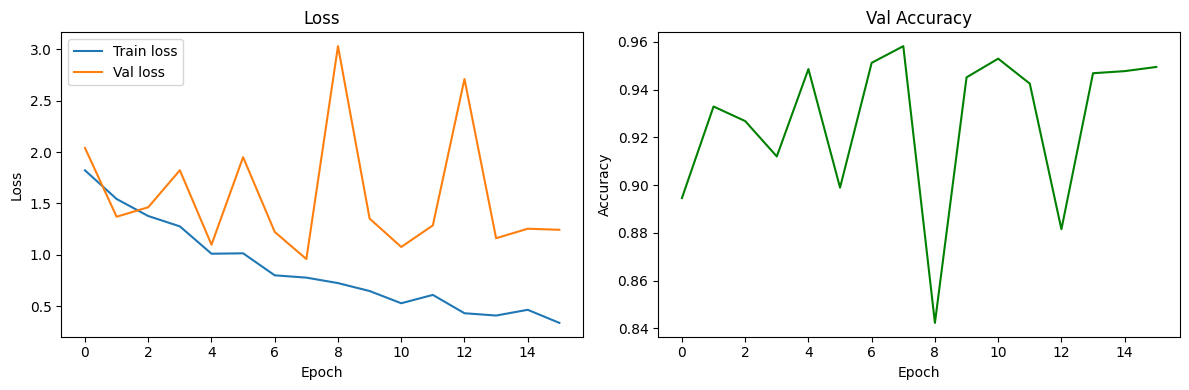

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train loss')
axes[0].plot(history['val_loss'],   label='Val loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].set_title('Loss')
axes[1].plot(history['val_acc'], color='green')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Val Accuracy')
plt.tight_layout()
plt.savefig(r'C:\Users\banan\50.021\training_curves_5sec.png')
plt.show()

In [22]:
model.eval()
all_scores, all_labels = [], []

with torch.no_grad():
    for specs, labels,tmie in test_loader:
        specs = specs.to(device)
        scores = torch.sigmoid(model(specs).squeeze(-1))
        all_scores  += scores.cpu().tolist()
        all_labels  += labels.cpu().int().tolist()

all_preds = [1 if s > 0.5 else 0 for s in all_scores]
fpr, tpr, _ = roc_curve(all_labels, all_scores)
eer = brentq(lambda x: 1 - x - interp1d(fpr, tpr)(x), 0, 1)

print("=" * 40)
print("TEST SET RESULTS")
print("=" * 40)
print(f"Accuracy : {accuracy_score(all_labels, all_preds):.4f}")
print(f"F1 Score : {f1_score(all_labels, all_preds):.4f}")
print(f"AUC-ROC  : {roc_auc_score(all_labels, all_scores):.4f}")
print(f"EER      : {eer:.4f}")
print("=" * 40)

TEST SET RESULTS
Accuracy : 0.9652
F1 Score : 0.9747
AUC-ROC  : 0.9944
EER      : 0.0395
